In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Para esta parte dentro del modelo ciclico se aborda la relación de dominación $x_1 \rightarrow x_2 \rightarrow x_3 \rightarrow x_1 $ y a partir del modelo anterior se proponen las siguientes ecuaciones para la toxicidad de cada población:
$$
\frac{dC_1}{dt} = S_1 C_E + k_1 C_2 - g_1
$$

$$
\frac{dC_2}{dt} = S_2 C_E + k_2 C_3 - g_2
$$

$$
\frac{dC_3}{dt} = S_3 C_E + k_3 C_1 - g_3
$$
Donde $S_i \cdot C_E$ hace referencia a las tasas de absorción de toxicidad del ambiente por parte de cada población. $k_i \cdot C_j$ Representa la cantidad de microplasticos transferida (bioacumulación) de la especie $j$ depredada por $i$  y $g_i$ representa las tasa de egestión de cada población.
De la referencia 2 "Coexistence versus extinction in the stochastic cyclic Lotka-Volterra model" bajo el enfoque determinista "Urn model" las ecuaciones que describen la evolución temporal de las densidaddes de especies $a(t),b(t)$ y $c(t)$ para las especies A, B y C están dadas por:
$$
\frac{da}{dt} = a[k_C b - k_B c]
$$

$$
\frac{db}{dt} = b[k_A c - k_C a]
$$

$$
\frac{dc}{dt} = c[k_B a - k_A b]
$$
Aplicando este mismo enfoque al sistema de tres especies tenemos entonces las ecuaciones:
$$
\frac{dx_1}{dt} = x_1[k_C x_2 - k_B x_3]
$$

$$
\frac{dx_2}{dt} = x_2[k_A x_3 - k_C x_1]
$$

$$
\frac{dx_3}{dt} = x_3[k_B x_1 - k_A x_2]
$$
Fundamentalmente estas son las ecuaciones que describen el sistema cuando ignoramos los efectos toxicologicos, si tenemos en cuenta que respecto al modelo (I) todas las especies deben tener una perdida en su rendimiento de depredación respecto a la especie que consumen, en el modelo I esta perdida la tenia unicamente el depredador, de esta forma tenemos que los terminos anteriores obedecen a $k_B=(a_1-d_1)$, $k_C=(a_2-d_2)$ y $k_A=(a_3-d_3)$. No existe un termino $\alpha=(r_{10}-d_1)$ como en el modelo I porque no es encesaria una tasa intrinseca de crecimiento de la presa, tampoco un termino $r_{20}=\gamma$ de mortalidad intrinseca del depredador.
Si agregamos los efectos toxicológicos del modelo se propone acoplar de la siguiente forma:
$$
\frac{dx_1}{dt} = x_1[(a_2-d_2)x_2 - r_1 C_1 - (a_1-d_1)x_3]
$$

$$
\frac{dx_2}{dt} = x_2[(a_3-d_3)x_3 - r_2 C_2 - (a_2-d_2)x_1]
$$

$$
\frac{dx_3}{dt} = x_3[(a_1-d_1)x_1 - r_3 C_3 - (a_3-d_3)x_2]
$$
A continuación se definen las variables y las condiciones iniciales que se van a usar a lo largo de la segunda parte del proyecto:

In [ ]:
# Condiciones iniciales
# Poblaciones iniciales
x1_0 = 100
x2_0 = 45
x3_0 = 20
C1_0 = 0
C2_0 = 0
C3_0 = 0
#Parametro de impacto de los microplasticos en cada población
r1 = 4.1
r2 = 4.0
r3 = 3.9
d1 = 0.02
d2 = 0.02
d3 = 0.02
a1 = 0.052
a2 = 0.052
a3 = 0.052
# Tasas de egestión
g1 = 0.0001
g2 = 0.0001
g3 = 0.0001
S1 = 0.34
S2 = 0.35
S3 = 0.36
# Bioconcentración
k1 = 0.002
k2 = 0.002
k3 = 0.002
CE = 0.09  # Toxicidad en el ambiente (Se asume constante)

In [ ]:
def f_c1(C2,S1,k1):
    return S1*CE+k1*C2-g1
def f_c2(C3,S2,k2):
    return S2*CE+k2*C3-g2
def f_c3(C1,S3,k3):
    return S3*CE+k3*C1-g3

In [ ]:
def f_x1(x1, x2, x3, d1 ,d2, r1, C1):
    return x1*((a2-d2)*x2-r1*C1-(a1-d1)*x3)
def f_x2(x1, x2, x3, d2 ,d3, r2, C2):
    return x2*((a3-d3)*x3-r2*C2-(a2-d2)*x1)
def f_x3(x1, x2, x3, d1 ,d3, r3, C3):
    return x3*((a1-d1)*x1-r3*C3-(a3-d3)*x2)

In [ ]:
def RungeKutta(Tmax,d1,d2,d3,r1,r2,r3,S1,S2,S3,k1,k2,k3):
    T=[]
    X1=[]
    X2=[]
    X3=[]
    x1=x1_0
    x2=x2_0
    x3=x3_0
    C1=C1_0
    C2=C2_0
    C3=C3_0
    h=0.0001
    t=0
    while (t<=Tmax):
        k1xx=f_c1(C2,S1,k1)
        k1yy=f_c2(C3,S2,k2)
        k1zz=f_c3(C1,S3,k3)
        k2xx=f_c1(C2+0.25*h*k1xx,S1,k1)
        k2yy=f_c2(C3+0.25*h*k1yy,S2,k2)
        k2zz=f_c3(C1+0.25*h*k1zz,S3,k3)
        k3xx=f_c1(C2+0.125*k1xx*h+0.125*k2xx*h,S1,k1)
        k3yy=f_c2(C3+0.125*k1yy*h+0.125*k2yy*h,S2,k2)
        k3zz=f_c3(C1+0.125*k1zz*h+0.125*k2zz*h,S3,k3)
        k4xx=f_c1(C2-0.5*k2xx*h+k3xx*h,S1,k1)
        k4yy=f_c2(C3-0.5*k2yy*h+k3yy*h,S2,k2)
        k4zz=f_c3(C1-0.5*k2zz*h+k3zz*h,S3,k3)
        k5xx=f_c1(C2+0.1875*k1xx*h+0.5625*k4xx*h,S1,k1)
        k5yy=f_c2(C3+0.1875*k1yy*h+0.5625*k4yy*h,S2,k2)
        k5zz=f_c3(C1+0.1875*k1zz*h+0.5625*k4zz*h,S3,k3)
        k6xx=f_c1(C2-(3/7)*k1xx*h+(2/7)*k2xx*h+(12/7)*k3xx*h-(12/7)*k4xx*h+(8/7)*k5xx*h,S1,k1)
        k6yy=f_c2(C3-(3/7)*k1yy*h+(2/7)*k2yy*h+(12/7)*k3yy*h-(12/7)*k4yy*h+(8/7)*k5yy*h,S2,k2)
        k6zz=f_c3(C1-(3/7)*k1zz*h+(2/7)*k2zz*h+(12/7)*k3zz*h-(12/7)*k4zz*h+(8/7)*k5zz*h,S3,k3)
        C1+=(h/90)*(7*k1xx+32*k3xx+12*k4xx+32*k5xx+7*k6xx)
        C2+=(h/90)*(7*k1yy+32*k3yy+12*k4yy+32*k5yy+7*k6yy)
        C3+=(h/90)*(7*k1zz+32*k3zz+12*k4zz+32*k5zz+7*k6zz)
        T.append(t)
        X1.append(x1)
        X2.append(x2)
        X3.append(x3)
        k1x=f_x1(x1,x2,x3,d1,d2,r1,C1)
        k1y=f_x2(x1,x2,x3,d2,d3,r2,C2)
        k1z=f_x3(x1,x2,x3,d3,d1,r3,C3)
        k2x=f_x1(x1+0.25*h,x2+0.25*k1x*h,x3+0.25*k1x*h,d1,d2,r1,C1)
        k2y=f_x2(x1+0.25*h,x2+0.25*k1y*h,x3+0.25*k1y*h,d2,d3,r2,C2)
        k2z=f_x3(x1+0.25*h,x2+0.25*k1z*h,x3+0.25*k1z*h,d3,d1,r3,C3)
        k3x=f_x1(x1+0.25*h,x2+0.125*k1x*h+0.125*k2x*h,x3+0.125*k1x*h+0.125*k2x*h,d1,d2,r1,C1)
        k3y=f_x2(x1+0.25*h,x2+0.125*k1y*h+0.125*k2y*h,x3+0.125*k1y*h+0.125*k2y*h,d2,d3,r2,C2)
        k3z=f_x3(x1+0.25*h,x2+0.125*k1z*h+0.125*k2z*h,x3+0.125*k1z*h+0.125*k2z*h,d3,d1,r3,C3)
        k4x=f_x1(x1+0.5*h,x2-0.5*k2x*h+k3x*h,x3-0.5*k2x*h+k3x*h,d1,d2,r1,C1)
        k4y=f_x2(x1+0.5*h,x2-0.5*k2y*h+k3y*h,x3-0.5*k2y*h+k3y*h,d2,d3,r2,C2)
        k4z=f_x3(x1+0.5*h,x2-0.5*k2z*h+k3z*h,x3-0.5*k2z*h+k3z*h,d3,d1,r3,C3)
        k5x=f_x1(x1+0.75*h,x2+0.1875*k1x*h+0.5625*k4x*h,x3+0.1875*k1x*h+0.5625*k4x*h,d1,d2,r1,C1)
        k5y=f_x2(x1+0.75*h,x2+0.1875*k1y*h+0.5625*k4y*h,x3+0.1875*k1y*h+0.5625*k4y*h,d2,d3,r2,C2)
        k5z=f_x3(x1+0.75*h,x2+0.1875*k1z*h+0.5625*k4z*h,x3+0.1875*k1z*h+0.5625*k4z*h,d3,d1,r3,C3)
        k6x=f_x1(x1+h,x2-(3/7)*k1x*h+(2/7)*k2x*h+(12/7)*k3x*h-(12/7)*k4x*h+(8/7)*k5x*h,x3-(3/7)*k1x*h+(2/7)*k2x*h+(12/7)*k3x*h-(12/7)*k4x*h+(8/7)*k5x*h,d1,d2,r1,C1)
        k6y=f_x2(x1+h,x2-(3/7)*k1y*h+(2/7)*k2y*h+(12/7)*k3y*h-(12/7)*k4y*h+(8/7)*k5y*h,x3-(3/7)*k1y*h+(2/7)*k2y*h+(12/7)*k3y*h-(12/7)*k4y*h+(8/7)*k5y*h,d2,d3,r2,C2)
        k6z=f_x3(x1+h,x2-(3/7)*k1z*h+(2/7)*k2z*h+(12/7)*k3z*h-(12/7)*k4z*h+(8/7)*k5z*h,x3-(3/7)*k1z*h+(2/7)*k2z*h+(12/7)*k3z*h-(12/7)*k4z*h+(8/7)*k5z*h,d3,d1,r3,C3)
        x1+=(h/90)*(7*k1x+32*k3x+12*k4x+32*k5x+7*k6x)
        x2+=(h/90)*(7*k1y+32*k3y+12*k4y+32*k5y+7*k6y)
        x3+=(h/90)*(7*k1z+32*k3z+12*k4z+32*k5z+7*k6z)
        t+=h
    plt.plot(T,X1,'#1f77b4', label='X1',linewidth=2)
    plt.plot(T,X2,'#ff7f0e', label='X2',linewidth=2)
    plt.plot(T,X3,'g', label='X3',linewidth=2)
    plt.xlabel('Tiempo',size=15)
    plt.ylabel('Población',size=15)
    plt.legend(fontsize=20,loc='center left',bbox_to_anchor=(1,0.5))
    plt.show()
    #Espacio de configuración:
    fig=plt.figure(figsize=(10,7))
    ax=fig.add_subplot(111,projection='3d')
    ax.plot(X1,X2,X3,color='r',linewidth=3)
    ax.set_xlabel('X1',size=20)
    ax.set_ylabel('X2',size=20)
    ax.set_zlabel('X3',size=20)
    ax.set_box_aspect([np.ptp(X1),np.ptp(X2),np.ptp(X3)])
    plt.subplots_adjust(left=0.05,right=0.95,top=0.95,bottom=0.05)
    plt.show()

# Caso a: (sin microplásticos) $r_{1}=r_{2}=r_{3}=0$

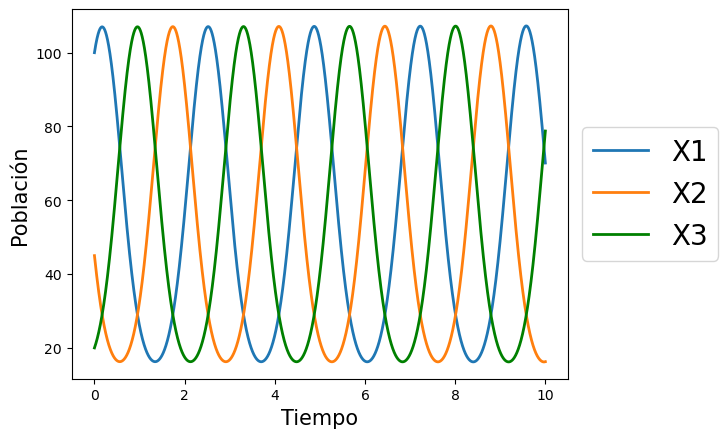

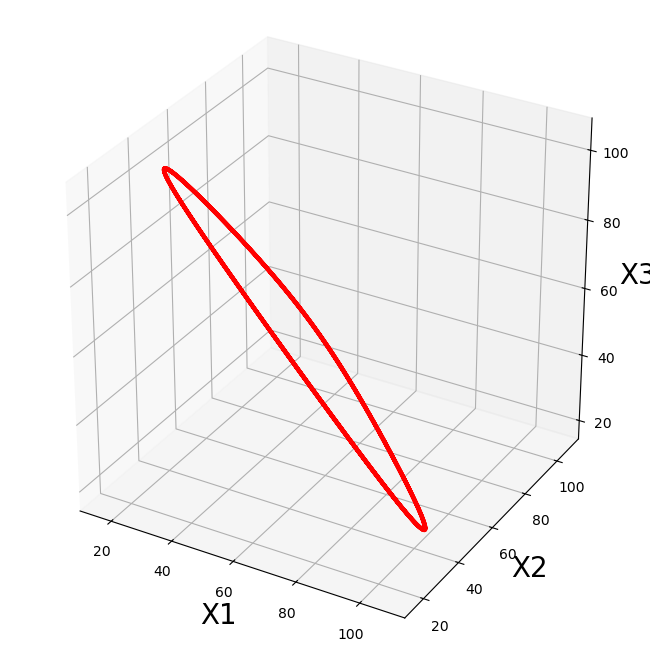

In [ ]:
RungeKutta(10,d1,d2,d3,0,0,0,0,0,0,0,0,0)

# Caso inicial con microplásticos : Las tres especies se extinguen a largo plazo

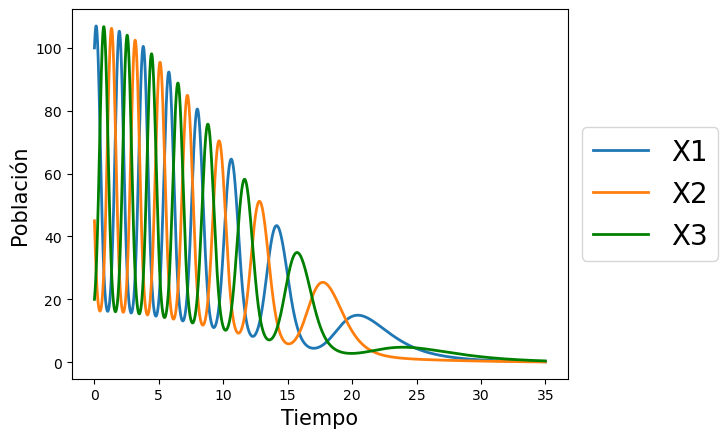

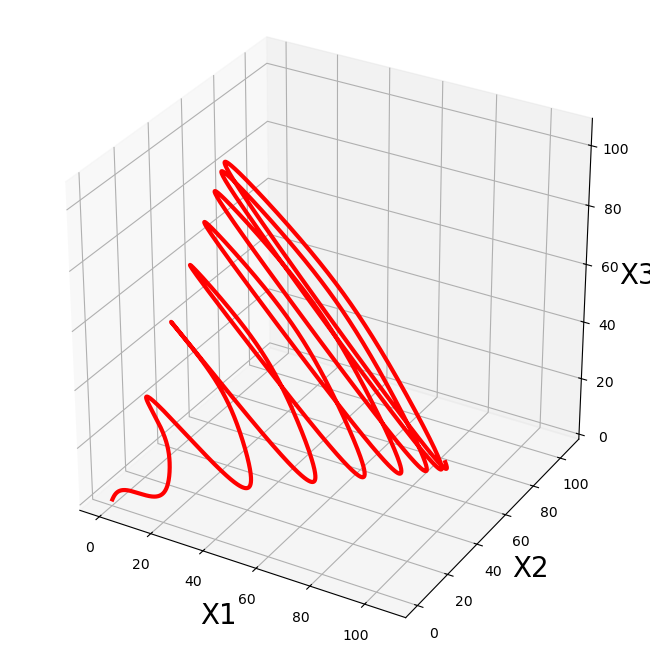

In [ ]:
RungeKutta(35, 0.01, 0.01, 0.01, 0.5, 0.5, 0.5, 0.2, 0.2, 0.2, 0.001, 0.001, 0.001)

# Los efectos de la bioacumulación son muy pequeños ($k_1=k_2=k_3=0.0000001$): Las poblaciones aumentan inicialmente (coexistencia) pero luego el sistema colapsa y todas las especies se extinguen

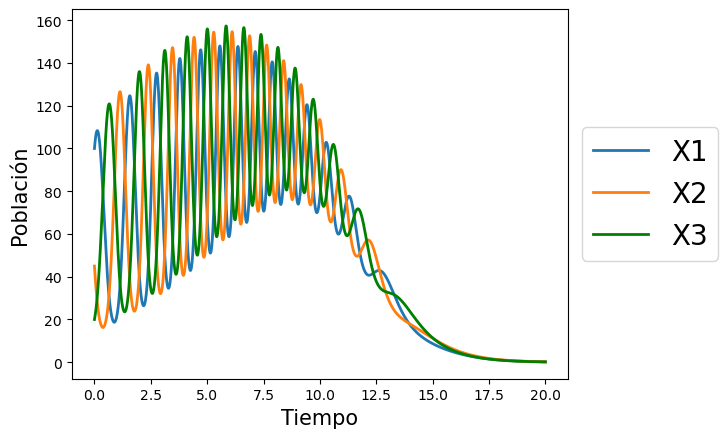

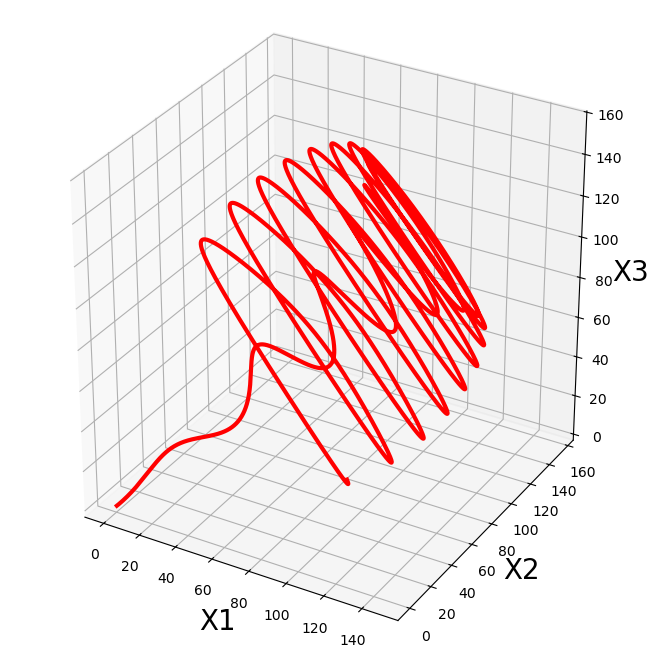

In [ ]:
RungeKutta(20,0.010,0.005,0.005,1.5,1.5,1.5,S1,S2,S3,0.0000001,0.0000001,0.0000001)

# Una de las especies se beneficia de la bioacumulación de toxicidad (mutualismo en caso de un parasito por ejemplo): Al largo plazo dos especies sobreviven mientras que la tercera se extingue

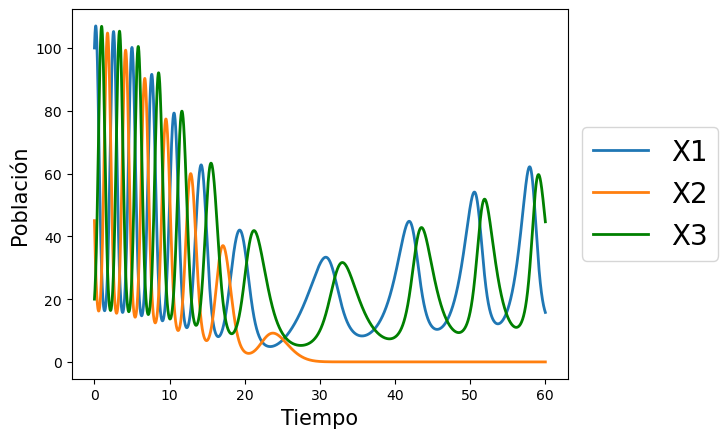

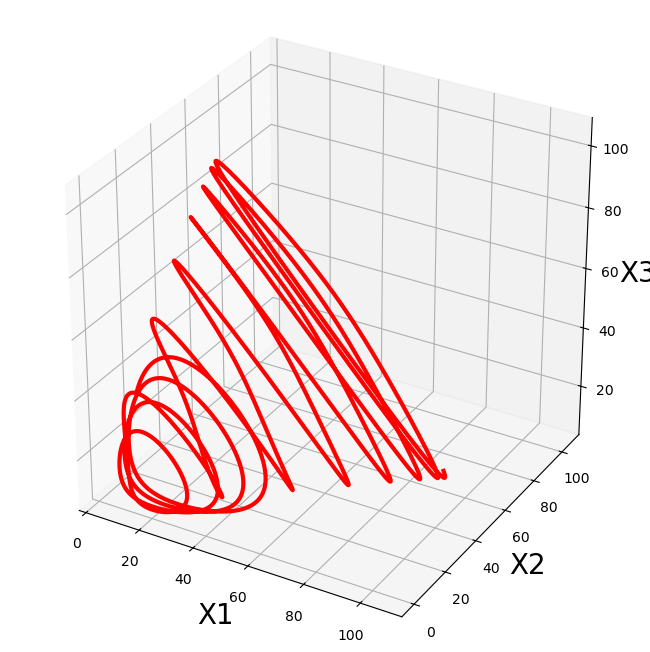

In [ ]:
RungeKutta(60, d1,d2, d3,-0.5, 0.5, 0.5, S1, S2, S3, k1, k2, k3)

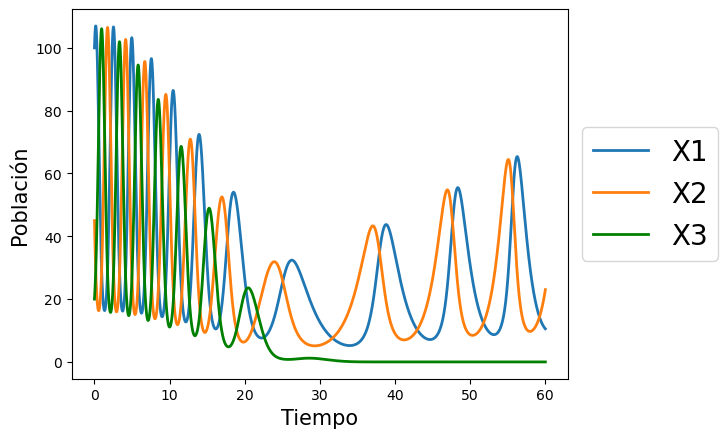

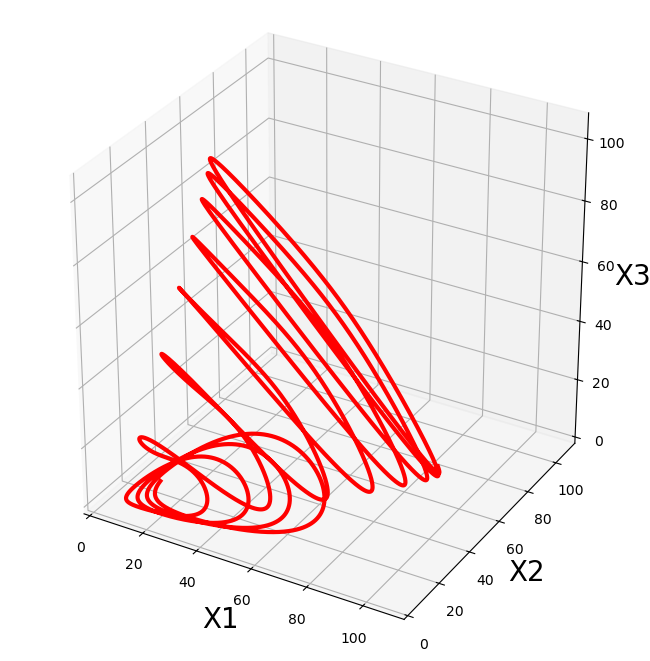

In [ ]:
RungeKutta(60, d1,d2, d3,0.5, -0.5, 0.5, S1, S2, S3, k1, k2, k3)

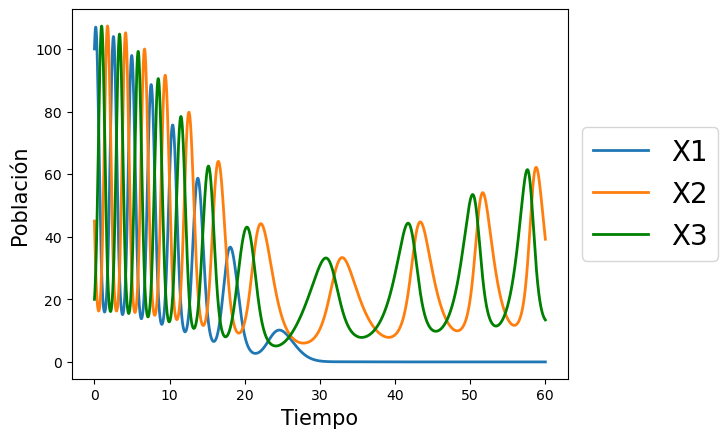

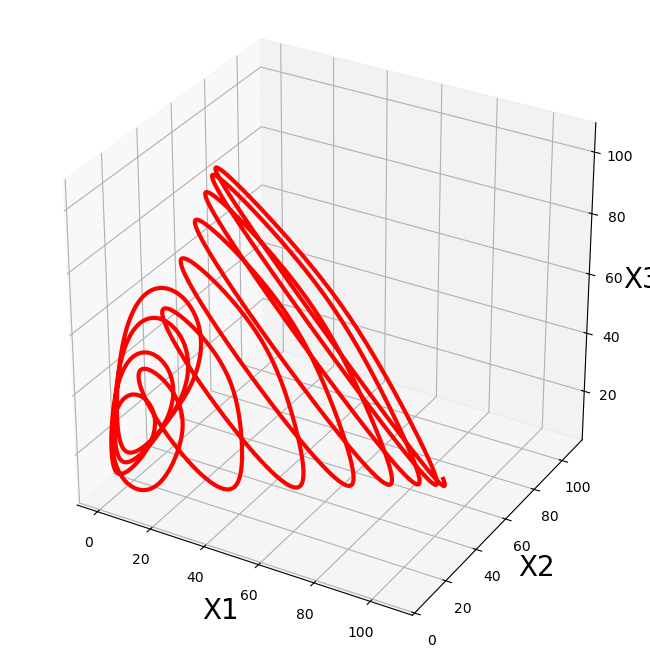

In [ ]:
RungeKutta(60, d1,d2, d3,0.5, 0.5, -0.5, S1, S2, S3, k1, k2, k3)

# Una especie se beneficia de la toxicidad, otra es inmune: sobrevive especie inmune(a largo plazo unica que sobrevive), la que se beneficia se extingue

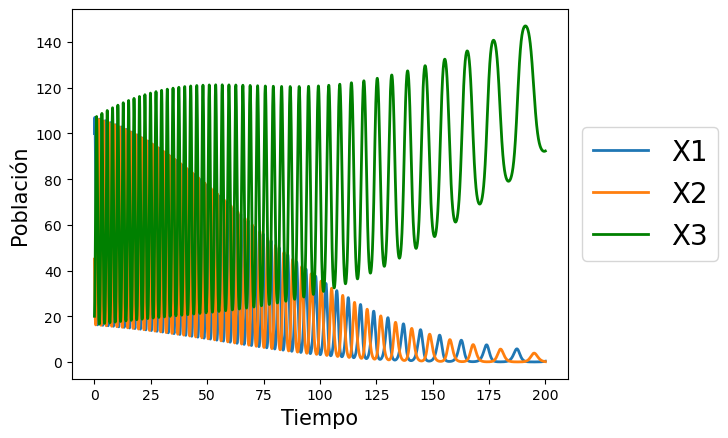

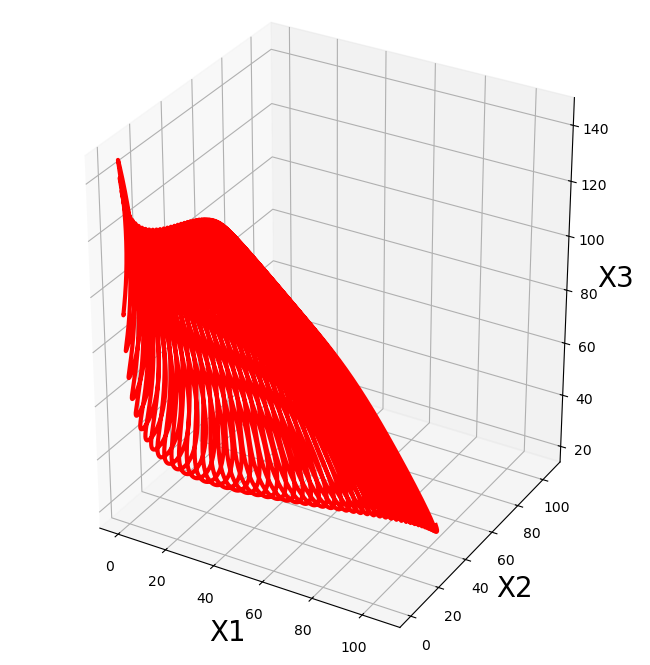

In [ ]:
RungeKutta(200, d1,d2, d3,-0.5, 0.5, 0, S1, S2, S3, k1, k2, k3)